In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
uploaded = files.upload()

Saving hospital_readmissions_30k.csv to hospital_readmissions_30k.csv


In [ ]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (30000, 12)


,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(
    df.isnull().sum().sort_values(ascending=False).head(20)
)

Number of rows: 30000
Number of columns: 12

Column names:
['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']

Data types:


,0
patient_id,int64
age,int64
gender,object
blood_pressure,object
cholesterol,int64
bmi,float64
diabetes,object
hypertension,object
medication_count,int64
length_of_stay,int64



Missing values:


,0
patient_id,0
age,0
gender,0
blood_pressure,0
cholesterol,0
bmi,0
diabetes,0
hypertension,0
medication_count,0
length_of_stay,0


In [ ]:
target_column = "readmitted_30_days"

print("Target column:", target_column)

print("\nUnique target values:")
print(df[target_column].unique())

print("\nTarget distribution:")
print(df[target_column].value_counts())

Target column: readmitted_30_days

Unique target values:
['Yes' 'No']

Target distribution:
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [ ]:
target_values = df[target_column].dropna().unique()

print("Original target values:")
print(target_values)

# If target is already numeric 0/1
if set(target_values).issubset({0, 1}):

    y = df[target_column].astype(int)

# If target is True/False
elif set(target_values).issubset({True, False}):

    y = df[target_column].astype(int)

# If target is Yes/No
else:

    y = (
        df[target_column]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "yes": 1,
            "no": 0,
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0
        })
    )

# Check for conversion problems
if y.isna().any():
    print("\nWARNING: Some target values could not be converted.")
    print(df.loc[y.isna(), target_column].value_counts())

    raise ValueError(
        "Target conversion failed. Check the unique target values."
    )

y = y.astype(int)

print("\nFinal target distribution:")
print(y.value_counts())

Original target values:
['Yes' 'No']

Final target distribution:
readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64


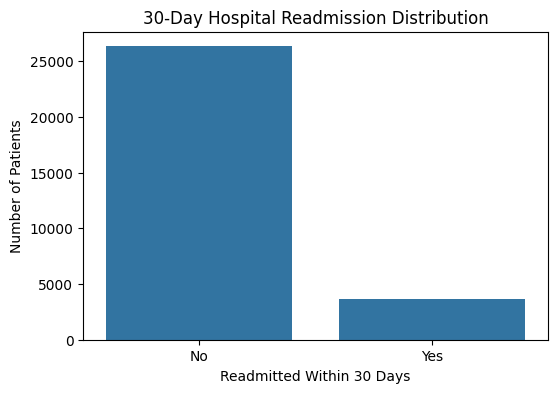

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No", "Yes"]
)

plt.show()

In [ ]:
X = df.drop(
    columns=[target_column]
)

# Remove common ID columns if they exist
id_columns = [
    col for col in X.columns
    if (
        "id" in col.lower()
        or "unnamed" in col.lower()
    )
]

if id_columns:
    print("Removing ID columns:")
    print(id_columns)

    X = X.drop(
        columns=id_columns
    )

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Removing ID columns:
['patient_id']

Feature shape: (30000, 10)
Target shape: (30000,)


,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination
0,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility
1,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility
2,89,Other,135/78,153,30.3,No,Yes,1,1,Home
3,84,Female,123/80,153,31.5,No,Yes,3,10,Home
4,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility


In [ ]:
numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Number of numerical features:",
      len(numerical_features))

print("Number of categorical features:",
      len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 5
Number of categorical features: 5

Numerical features:
['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

Categorical features:
['gender', 'blood_pressure', 'diabetes', 'hypertension', 'discharge_destination']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 24000
Testing samples: 6000

Training target distribution:
readmitted_30_days
0    21061
1     2939
Name: count, dtype: int64

Testing target distribution:
readmitted_30_days
0    5265
1     735
Name: count, dtype: int64


In [ ]:
numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        LogisticRegression(
            penalty="l2",
            C=1.0,
            max_iter=1000,
            solver="liblinear"
        )
    )
])

model.fit(
    X_train,
    y_train
)

print("Model training completed!")
print("Algorithm: Logistic Regression")
print("Regularization: L2")

Model training completed!
Algorithm: Logistic Regression
Regularization: L2


In [ ]:
y_pred = model.predict(
    X_test
)

y_probability = model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(y_probability[:10])

Predictions generated successfully!

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.20490482 0.16400034 0.06459911 0.15620936 0.22119948 0.09666646
 0.14056907 0.29560398 0.18690396 0.07233333]


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("========== MODEL PERFORMANCE ==========")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

========== MODEL PERFORMANCE ==========
Accuracy : 0.8775
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5373


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Readmission",
            "Readmitted"
        ],
        zero_division=0
    )
)

                precision    recall  f1-score   support

No Readmission       0.88      1.00      0.93      5265
    Readmitted       0.00      0.00      0.00       735

      accuracy                           0.88      6000
     macro avg       0.44      0.50      0.47      6000
  weighted avg       0.77      0.88      0.82      6000



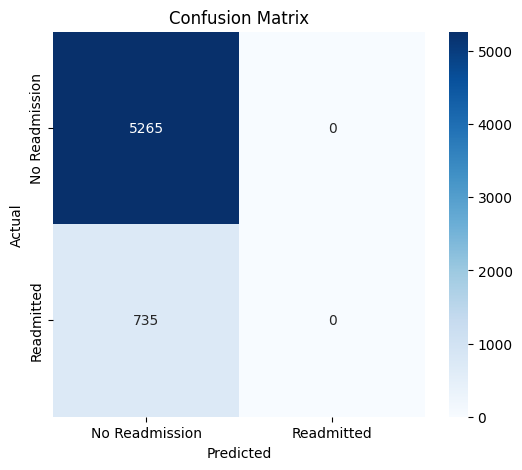

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Readmission",
        "Readmitted"
    ],
    yticklabels=[
        "No Readmission",
        "Readmitted"
    ]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

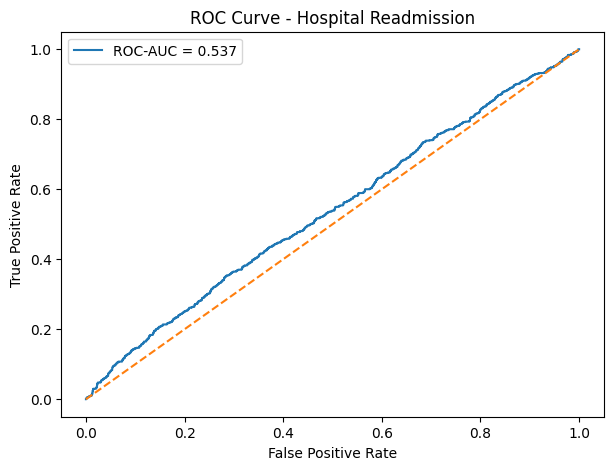

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Hospital Readmission"
)

plt.legend()

plt.show()

In [ ]:
thresholds_to_test = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

threshold_results = []

for threshold in thresholds_to_test:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Threshold,Precision,Recall,F1 Score
0,0.3,0.180328,0.029932,0.051342
1,0.4,0.222222,0.005442,0.010624
2,0.5,0.000000,0.000000,0.000000
3,0.6,0.000000,0.000000,0.000000
4,0.7,0.000000,0.000000,0.000000


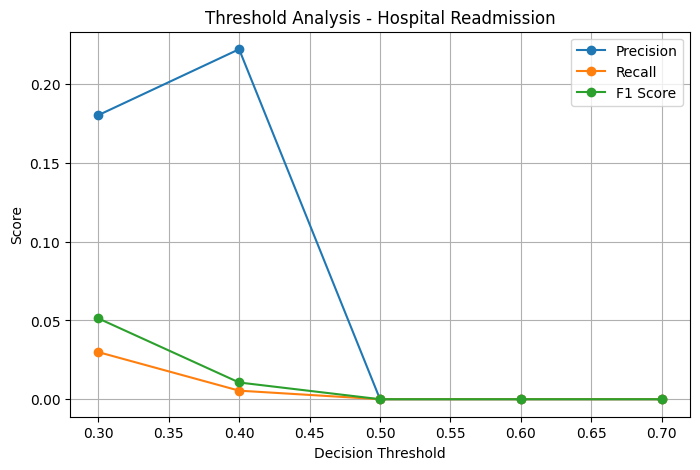

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold Analysis - Hospital Readmission"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
fitted_preprocessor = (
    model.named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficients = (
    model
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Top 20 features:")
display(
    coefficient_df.head(20)
)

Top 20 features:


,Feature,Coefficient,Absolute_Coefficient
301,categorical__blood_pressure_119/83,1.560024,1.560024
1183,categorical__blood_pressure_147/97,1.515047,1.515047
864,categorical__blood_pressure_137/88,1.450967,1.450967
399,categorical__blood_pressure_122/88,1.439950,1.439950
809,categorical__blood_pressure_135/95,1.413437,1.413437
565,categorical__blood_pressure_127/99,1.384209,1.384209
1252,categorical__blood_pressure_150/73,1.340658,1.340658
597,categorical__blood_pressure_129/100,1.296607,1.296607
1474,categorical__blood_pressure_157/78,1.249315,1.249315
769,categorical__blood_pressure_134/86,1.249275,1.249275


In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(results)

,Metric,Score
0,Accuracy,0.877500
1,Precision,0.000000
2,Recall,0.000000
3,F1 Score,0.000000
4,ROC-AUC,0.537346
